In [1]:
import pandas as pd

df = pd.read_csv("WorldEnergy.csv")

print(df.shape)
print(df.columns.tolist())
print(df.head())

(23195, 130)
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh

In [3]:
selected_countries = ["China", "United States", "India", "Germany", "Japan"]

for country in selected_countries:
    print(country, country in df["country"].unique())

China True
United States True
India True
Germany True
Japan True


In [4]:
selected_countries = ["China", "United States", "India", "Germany", "Japan"]

data = df[
    (df["country"].isin(selected_countries)) &
    (df["year"] >= 2000) &
    (df["year"] <= 2022)
]

anova_data = data[["country", "year", "primary_energy_consumption"]].dropna()

print(anova_data.head())
print(anova_data.shape)
print(anova_data["country"].value_counts())

     country  year  primary_energy_consumption
4547   China  2000                   11800.284
4548   China  2001                   12470.063
4549   China  2002                   13580.491
4550   China  2003                   15818.756
4551   China  2004                   18509.137
(115, 3)
country
China            23
Germany          23
India            23
Japan            23
United States    23
Name: count, dtype: int64


In [5]:
from scipy.stats import f_oneway

china = anova_data[anova_data["country"] == "China"]["primary_energy_consumption"]
usa = anova_data[anova_data["country"] == "United States"]["primary_energy_consumption"]
india = anova_data[anova_data["country"] == "India"]["primary_energy_consumption"]
germany = anova_data[anova_data["country"] == "Germany"]["primary_energy_consumption"]
japan = anova_data[anova_data["country"] == "Japan"]["primary_energy_consumption"]

f_statistic, p_value = f_oneway(china, usa, india, germany, japan)

print("One-way ANOVA Result")
print("F-statistic:", f_statistic)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Conclusion: Reject H0")
    print("There is a statistically significant difference in mean primary energy consumption among the selected countries.")
else:
    print("Conclusion: Fail to reject H0")
    print("There is no statistically significant difference in mean primary energy consumption among the selected countries.")

One-way ANOVA Result
F-statistic: 161.28887828001962
p-value: 4.631611731871997e-45
Conclusion: Reject H0
There is a statistically significant difference in mean primary energy consumption among the selected countries.


<Figure size 1000x600 with 0 Axes>

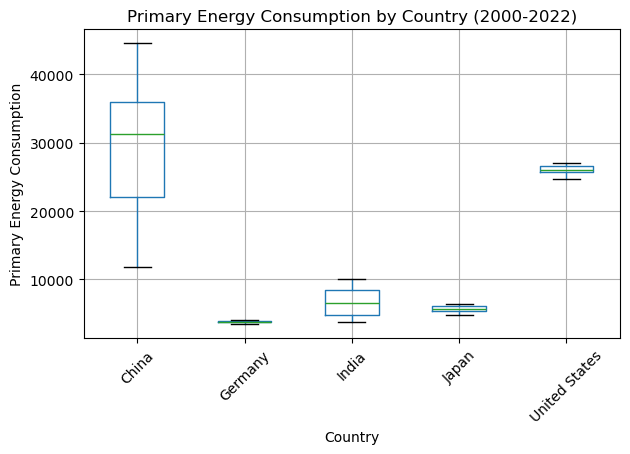

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
anova_data.boxplot(column="primary_energy_consumption", by="country")

plt.title("Primary Energy Consumption by Country (2000-2022)")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Primary Energy Consumption")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Dataset shape:
(23195, 130)

Dataset columns:
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_

<Figure size 1000x600 with 0 Axes>

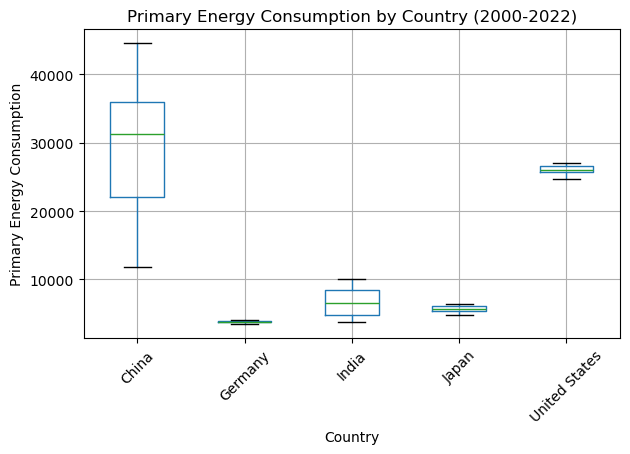

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Step 1: Load the dataset
df = pd.read_csv("WorldEnergy.csv")

print("Dataset shape:")
print(df.shape)

print("\nDataset columns:")
print(df.columns.tolist())

print("\nFirst five rows:")
print(df.head())

# Step 2: Select countries and year range
selected_countries = ["China", "United States", "India", "Germany", "Japan"]

data = df[
    (df["country"].isin(selected_countries)) &
    (df["year"] >= 2000) &
    (df["year"] <= 2022)
]

# Step 3: Select variables for ANOVA
anova_data = data[["country", "year", "primary_energy_consumption"]].dropna()

print("\nSelected data preview:")
print(anova_data.head())

print("\nSelected data shape:")
print(anova_data.shape)

print("\nNumber of records for each country:")
print(anova_data["country"].value_counts())

print("\nMean primary energy consumption by country:")
print(anova_data.groupby("country")["primary_energy_consumption"].mean())

# Step 4: Prepare groups for one-way ANOVA
china = anova_data[anova_data["country"] == "China"]["primary_energy_consumption"]
usa = anova_data[anova_data["country"] == "United States"]["primary_energy_consumption"]
india = anova_data[anova_data["country"] == "India"]["primary_energy_consumption"]
germany = anova_data[anova_data["country"] == "Germany"]["primary_energy_consumption"]
japan = anova_data[anova_data["country"] == "Japan"]["primary_energy_consumption"]

# Step 5: Perform one-way ANOVA
f_statistic, p_value = f_oneway(china, usa, india, germany, japan)

print("\nOne-way ANOVA Result")
print("F-statistic:", f_statistic)
print("p-value:", p_value)

# Step 6: Interpret the result
alpha = 0.05

print("\nHypotheses:")
print("H0: The mean primary energy consumption is equal among the selected countries.")
print("HA: At least one country has a different mean primary energy consumption.")

if p_value < alpha:
    print("\nConclusion: Reject H0")
    print("There is a statistically significant difference in mean primary energy consumption among the selected countries.")
else:
    print("\nConclusion: Fail to reject H0")
    print("There is no statistically significant difference in mean primary energy consumption among the selected countries.")

# Step 7: Visualize the data using boxplot
plt.figure(figsize=(10, 6))
anova_data.boxplot(column="primary_energy_consumption", by="country")

plt.title("Primary Energy Consumption by Country (2000-2022)")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Primary Energy Consumption")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Lab3_ANOVA_Boxplot.png")
plt.show()